In [ ]:
!pip install regex

In [ ]:
!pip install nltk

In [ ]:
!pip install wordcloud

In [43]:
import pandas as pd
import regex as re
import matplotlib.pyplot as plt
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import warnings

In [20]:
warnings.filterwarnings("ignore")

In [21]:
download('stopwords')
download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nahue\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nahue\AppData\Roaming\nltk_data...


True

# Sistema de detección de enlaces spam

Queremos implementar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

## Paso 1: Carga del conjunto de datos

In [10]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/NLP-project-tutorial/main/url_spam.csv')

df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True
...,...,...
2994,https://www.smartcitiesworld.net/news/news/dee...,False
2995,https://www.youtube.com/watch,True
2996,https://techcrunch.com/2019/07/04/an-optimisti...,False
2997,https://www.technologyreview.com/2019/12/20/13...,False


# Paso 2: Preprocesa los enlaces

Utiliza lo visto en este módulo para transformar los datos para compatibilizarlos con el modelo que queremos entrenar. Segmenta las URLs en partes según sus signos de puntuación, elimina las stopwords, lematiza, etcétera.

Primero debemos eliminar los duplicados porque puede hacer que nuestro modelo sufra de overfitting

In [12]:
df.shape

(2999, 2)

In [13]:
df = df.drop_duplicates()
df = df.reset_index(inplace=False, drop=True)
df.shape

(2369, 2)

A continuacion procesaremos las urls segmentandolas en distintos grupos segun lo que hemos dado en este tema

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_url(url):
    url = re.sub(r"https?://", "", url) # Eliminar protocolo htttps
    url = re.sub(r"[^\w]", " ", url) # Separar por símbolos
    url = url.lower() # Minúsculas
    tokens = url.split() # Tokenizar
    clean_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Eliminar stopwords y lematizar
    return " ".join(clean_tokens)

df["url_clean"] = df["url"].apply(preprocess_url)

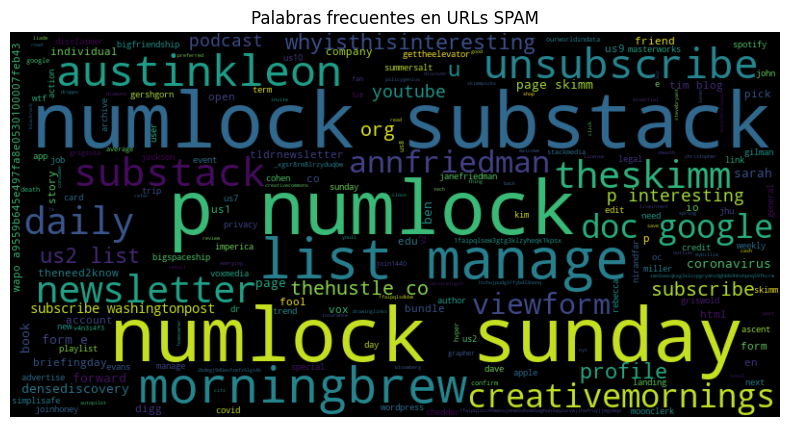

In [35]:
spam_words = " ".join(df[df["is_spam"] == 1]["url_clean"])
wc_spam = WordCloud(width=800, height=400, background_color='black').generate(spam_words)

plt.figure(figsize=(10,5))
plt.imshow(wc_spam, interpolation="bilinear")
plt.title("Palabras frecuentes en URLs SPAM")
plt.axis("off")
plt.show()


Separamos train y test

In [36]:
X = df["url_clean"]
y = df["is_spam"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Vamos a Vectorizar las X, esto transforma la muestra que ahora mismo es ttexto a una mattriz numerica que representa la importancia relativa de cada elemento

In [39]:
vectorizer = TfidfVectorizer(max_features=5000,
                             max_df=0.8,
                             min_df=5)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


Creamos el modelo

In [40]:
model = SVC(kernel='linear')
model.fit(X_train_tfidf, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Evaluacion del modelo

In [47]:
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)


accuracy

0.9641350210970464

### Optimizacion del modelo usando GridSearch

In [53]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_tfidf, y_train)

grid_search.best_params_



Fitting 5 folds for each of 16 candidates, totalling 80 fits


{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

In [54]:
model_opt = SVC(C=10, gamma='scale', kernel='rbf')

model_opt.fit(X_train_tfidf, y_train)

y_pred_opt = model_opt.predict(X_test_tfidf)

accuracy_opt = accuracy_score(y_test, y_pred_opt)

accuracy_opt

0.9620253164556962

# Conclusion

En este caso el modelo original es mas optimo que el optimizado, esto puede deberse al azar a la hora de dividir el dataset o a alguna fluctuacion estadistica o que quizas nuestro modelo base al tener el kernel lineal este generalizando mejor que en el optimizado. En todo caso hemos conseguido que nuestro modelo rinda en el 96/100 de las ocasiones 